# 02 · Churn Overview: How Big Is the Problem?

**Questions for the retention manager**
1. How many customers are we losing, and what share of the base is that?
2. How much recurring revenue walks out of the door?
3. Does churn differ by basic customer profile (gender, age, household)?

> **How to read revenue figures:** in this dataset, `Churn = Yes` means the customer left **within the last month**. *Monthly recurring revenue (MRR) lost* is the sum of churners' monthly bills. *Annualised revenue lost* is that MRR × 12, which is what the business would have billed those customers over a year had they stayed.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.churn_utils import (load_clean, set_theme, save_fig, churn_table, churn_bar,
                             BLUE, ORANGE, GREY, INK, pct_axis)

set_theme()
df = load_clean()
print(df.shape)

(7043, 26)


## 1. Headline KPIs

In [2]:
n_customers = len(df)
n_churned = int(df["churn_flag"].sum())
churn_rate = df["churn_flag"].mean()
total_mrr = df["MonthlyCharges"].sum()
mrr_lost = df.loc[df["churn_flag"] == 1, "MonthlyCharges"].sum()
arr_lost = mrr_lost * 12
avg_bill_churned = df.loc[df["churn_flag"] == 1, "MonthlyCharges"].mean()
avg_bill_retained = df.loc[df["churn_flag"] == 0, "MonthlyCharges"].mean()
lifetime_billed_churned = df.loc[df["churn_flag"] == 1, "TotalCharges"].sum()

kpis = pd.DataFrame({
    "KPI": [
        "Customers in base",
        "Customers lost (churned)",
        "Churn rate",
        "Total monthly recurring revenue (MRR)",
        "MRR lost to churn",
        "Share of MRR lost",
        "Annualised revenue lost (MRR lost × 12)",
        "Avg monthly bill: churned",
        "Avg monthly bill: retained",
    ],
    "Value": [
        f"{n_customers:,}",
        f"{n_churned:,}",
        f"{churn_rate:.1%}",
        f"${total_mrr:,.0f}",
        f"${mrr_lost:,.0f}",
        f"{mrr_lost / total_mrr:.1%}",
        f"${arr_lost:,.0f}",
        f"${avg_bill_churned:,.2f}",
        f"${avg_bill_retained:,.2f}",
    ],
}).set_index("KPI")
kpis

,Value
KPI,
Customers in base,"7,043"
Customers lost (churned),"1,869"
Churn rate,26.5%
Total monthly recurring revenue (MRR),"$456,117"
MRR lost to churn,"$139,131"
Share of MRR lost,30.5%
Annualised revenue lost (MRR lost × 12),"$1,669,570"
Avg monthly bill: churned,$74.44
Avg monthly bill: retained,$61.27


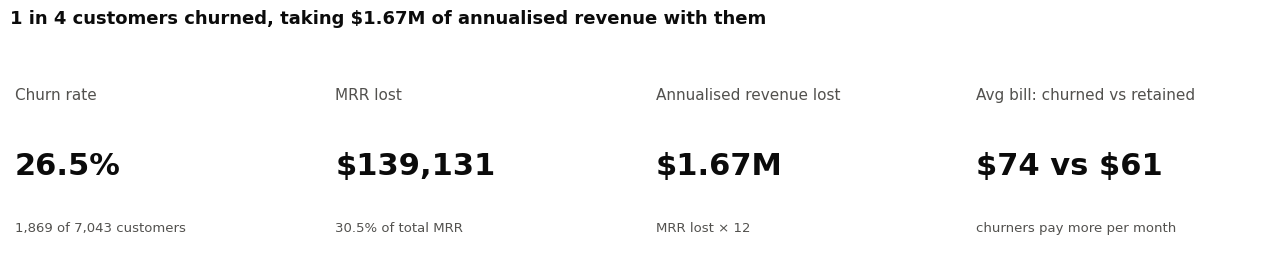

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 2.6))
tiles = [
    ("Churn rate", f"{churn_rate:.1%}", f"{n_churned:,} of {n_customers:,} customers"),
    ("MRR lost", f"${mrr_lost:,.0f}", f"{mrr_lost / total_mrr:.1%} of total MRR"),
    ("Annualised revenue lost", f"${arr_lost / 1e6:,.2f}M", "MRR lost × 12"),
    ("Avg bill: churned vs retained", f"${avg_bill_churned:,.0f} vs ${avg_bill_retained:,.0f}",
     "churners pay more per month"),
]
for ax, (label, value, sub) in zip(axes, tiles):
    ax.set_axis_off()
    ax.text(0, 0.78, label, fontsize=11, color=GREY, transform=ax.transAxes)
    ax.text(0, 0.38, value, fontsize=22, fontweight="bold", color=INK, transform=ax.transAxes)
    ax.text(0, 0.08, sub, fontsize=9.5, color=GREY, transform=ax.transAxes)
fig.suptitle("1 in 4 customers churned, taking $1.67M of annualised revenue with them",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "01_kpi_summary")
plt.show()

## 2. Churned vs retained: customers and revenue

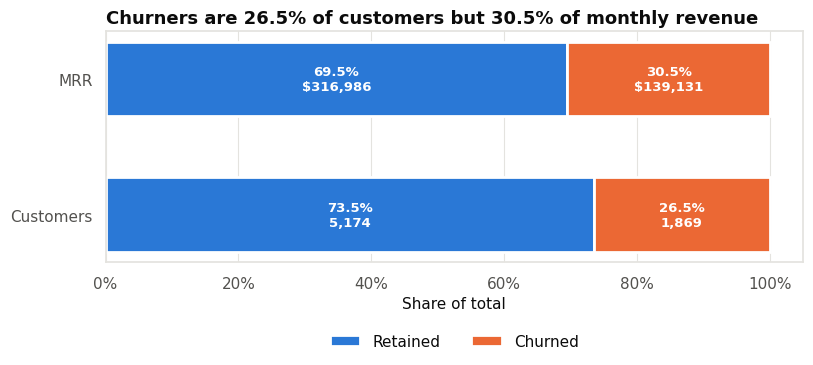

,Customers,MRR
Churn,,
Retained,5174,316985.75
Churned,1869,139130.85


In [4]:
split = pd.DataFrame({
    "Customers": df.groupby("Churn")["churn_flag"].size(),
    "MRR": df.groupby("Churn")["MonthlyCharges"].sum(),
}).loc[["No", "Yes"]].rename(index={"No": "Retained", "Yes": "Churned"})
share = split / split.sum()

fig, ax = plt.subplots(figsize=(9, 3))
left = pd.Series(0.0, index=share.columns)
for status, color in [("Retained", BLUE), ("Churned", ORANGE)]:
    ax.barh(share.columns, share.loc[status], left=left, color=color, height=0.55,
            edgecolor="white", linewidth=2, label=status)
    for i, col in enumerate(share.columns):
        raw_val = split.loc[status, col]
        txt = f"{share.loc[status, col]:.1%}\n" + (f"{raw_val:,.0f}" if col == "Customers" else f"${raw_val:,.0f}")
        ax.text(left[col] + share.loc[status, col] / 2, i, txt, ha="center", va="center",
                color="white", fontsize=9.5, fontweight="bold")
    left += share.loc[status]
pct_axis(ax, "x")
ax.set_xlabel("Share of total")
ax.set_title("Churners are 26.5% of customers but 30.5% of monthly revenue")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)
ax.grid(axis="y", visible=False)
save_fig(fig, "02_customers_vs_revenue_share")
plt.show()
split

## 3. Churn by customer profile

In [5]:
demo_cols = {"gender": "Gender", "SeniorCitizen": "Senior citizen", "Partner": "Has partner", "Dependents": "Has dependents"}
demo_tables = []
for col, label in demo_cols.items():
    t = churn_table(df, col).reset_index().rename(columns={col: "level"})
    t.insert(0, "attribute", label)
    demo_tables.append(t)
demo = pd.concat(demo_tables, ignore_index=True)
demo_display = demo.assign(
    churn_rate=demo["churn_rate"].map("{:.1%}".format),
    share_of_customers=demo["share_of_customers"].map("{:.1%}".format),
    mrr_lost=demo["mrr_lost"].map("${:,.0f}".format),
)[["attribute", "level", "customers", "share_of_customers", "churned", "churn_rate", "mrr_lost"]]
demo_display

,attribute,level,customers,share_of_customers,churned,churn_rate,mrr_lost
0,Gender,Female,3488,49.5%,939,26.9%,"$70,249"
1,Gender,Male,3555,50.5%,930,26.2%,"$68,882"
2,Senior citizen,Yes,1142,16.2%,476,41.7%,"$38,420"
3,Senior citizen,No,5901,83.8%,1393,23.6%,"$100,711"
4,Has partner,No,3641,51.7%,1200,33.0%,"$85,741"
5,Has partner,Yes,3402,48.3%,669,19.7%,"$53,390"
6,Has dependents,No,4933,70.0%,1543,31.3%,"$115,376"
7,Has dependents,Yes,2110,30.0%,326,15.5%,"$23,754"


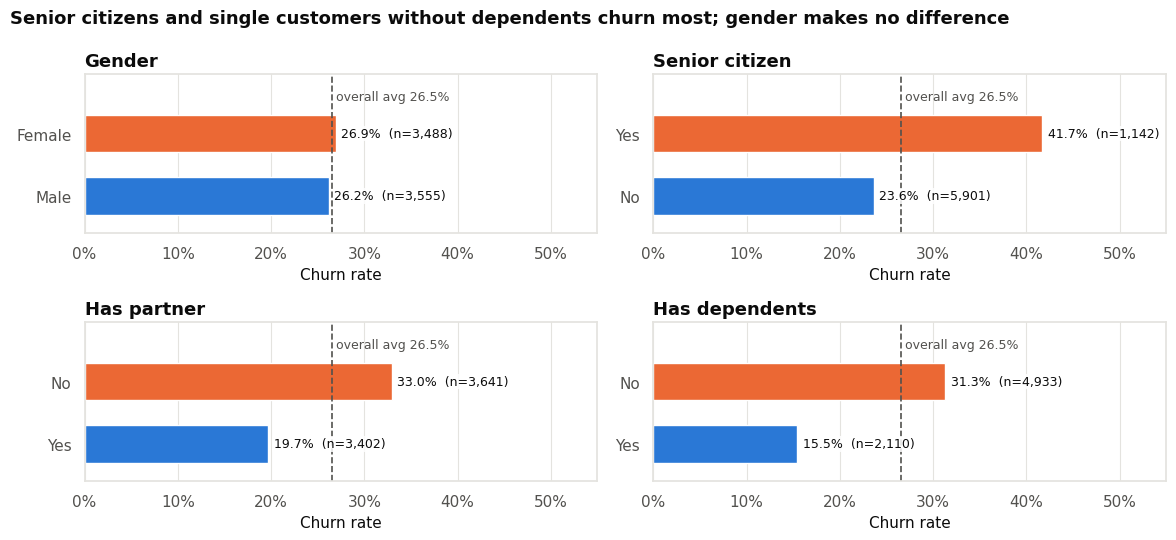

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5.5))
for ax, (col, label) in zip(axes.flat, demo_cols.items()):
    churn_bar(df, col, label, ax=ax, overall=churn_rate)
    ax.set_xlim(0, 0.55)
fig.suptitle("Senior citizens and single customers without dependents churn most; gender makes no difference",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "03_churn_by_demographics")
plt.show()

In [7]:
def gap(col, hi, lo):
    r = df.groupby(col)["churn_flag"].mean()
    return r[hi], r[lo], r[hi] / r[lo]

for col, hi, lo in [("SeniorCitizen", "Yes", "No"), ("Partner", "No", "Yes"),
                    ("Dependents", "No", "Yes"), ("gender", "Female", "Male")]:
    a, b, ratio = gap(col, hi, lo)
    print(f"{col:13s}: {hi} {a:.1%} vs {lo} {b:.1%}  -> {ratio:.2f}x")

SeniorCitizen: Yes 41.7% vs No 23.6%  -> 1.77x
Partner      : No 33.0% vs Yes 19.7%  -> 1.68x
Dependents   : No 31.3% vs Yes 15.5%  -> 2.02x
gender       : Female 26.9% vs Male 26.2%  -> 1.03x


## Key Takeaways

- **1,869 of 7,043 customers churned: a 26.5% churn rate**, or roughly 1 in 4.
- **$139,131 of monthly recurring revenue was lost.** That is 30.5% of the $456,117 MRR base, or **$1.67M a year** if those customers are not replaced.
- **Churners are more valuable than average:** they paid **$74.44/month vs $61.27** for retained customers. Revenue share lost (30.5%) is higher than customer share lost (26.5%).
- **Senior citizens churn at 41.7% vs 23.6%** for non-seniors (1.77×). They are only 16.2% of customers but account for $38,420 of lost MRR.
- **Household matters:** customers without a partner churn at 33.0% vs 19.7% with one (1.68×). Customers without dependents churn at 31.3% vs 15.5% (2.02×), and they make up $115,376 (83%) of lost MRR.
- **Gender makes no practical difference** (26.9% female vs 26.2% male), so it can be ignored for targeting.
- Demographics show *who* leaves, but these are not things the business can change. Notebook 03 looks at product and contract drivers, which it can act on.